# 🧪 G05 — Tests Pipeline
**AG News | DistilBERT | P01 Benchmark Optimiseurs**

Ce notebook teste chaque composant du projet étape par étape.

## ✅ CELLULE 0 — Setup & Imports

In [1]:
import sys, os
# Ajouter la racine du projet au path
PROJECT_ROOT = os.path.abspath('..')  # si notebook dans notebooks/
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('Python :', sys.version)
print('Racine projet :', PROJECT_ROOT)

# Vérification des imports critiques
import torch
import transformers
import datasets
import sklearn
import matplotlib
import pandas as pd
import numpy as np

print('\n--- Versions ---')
print('torch       :', torch.__version__)
print('transformers:', transformers.__version__)
print('datasets    :', datasets.__version__)
print('sklearn     :', sklearn.__version__)
print('Device      :', 'GPU ✓' if torch.cuda.is_available() else 'CPU')

Python : 3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]
Racine projet : c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews

--- Versions ---
torch       : 2.2.2+cpu
transformers: 4.57.3
datasets    : 4.4.2
sklearn     : 1.8.0
Device      : CPU


## ✅ CELLULE 1 — Test Config

In [2]:
from src.config import get_config

# Teste les 3 modes
for mode in ['cpu_low', 'cpu_mid', 'gpu']:
    cfg = get_config(mode)
    print(f'Mode {mode}: trials={cfg.search.n_trials}, max_steps={cfg.training.max_steps}, max_len={cfg.data.max_length}')

print('\n--- Config cpu_low détaillée ---')
cfg = get_config('cpu_low')
cfg.summary()

Mode cpu_low: trials=12, max_steps=60, max_len=64
Mode cpu_mid: trials=20, max_steps=100, max_len=128
Mode gpu: trials=30, max_steps=500, max_len=256

--- Config cpu_low détaillée ---
  PROJET   : G05_AGNews_DistilBERT_P01
  DEVICE   : cpu
  DATASET  : ag_news (4 classes)
  MODÈLE   : distilbert-base-uncased
  RUNS     : 12 trials Random Search
  OPTIM.   : adamw, sgd, adafactor
  MAX STEPS: 60
  LR RANGE : [1e-06, 5e-04]
  SEED     : 42


## ✅ CELLULE 2 — Test Chargement Données

In [3]:
from src.data_loader import load_ag_news_raw, balanced_subsample, set_seed

set_seed(42)
print('Chargement AG News...')
raw = load_ag_news_raw()

print(f'Train complet : {len(raw["train"])} exemples')
print(f'Test complet  : {len(raw["test"])} exemples')
print(f'Classes       : {raw["train"].features["label"].names}')

# Exemple d'article
print('\n--- Exemple ---')
ex = raw['train'][0]
print('Label :', ex['label'])
print('Texte :', ex['text'][:200], '...')

Chargement AG News...
  Chargement AG News depuis HuggingFace...
  Train : 120000 exemples
  Test  : 7600 exemples
Train complet : 120000 exemples
Test complet  : 7600 exemples
Classes       : ['World', 'Sports', 'Business', 'Sci/Tech']

--- Exemple ---
Label : 2
Texte : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again. ...


## ✅ CELLULE 3 — Test Sous-échantillonnage

In [4]:
from src.data_loader import balanced_subsample
from collections import Counter

texts, labels = balanced_subsample(raw['train'], num_classes=4, n_per_class=10, seed=42)

print(f'Taille totale : {len(texts)} exemples')
print(f'Distribution  : {dict(Counter(labels))}')
print('✓ Distribution équilibrée' if len(set(Counter(labels).values())) == 1 else '✗ Déséquilibré !')

Taille totale : 40 exemples
Distribution  : {3: 10, 2: 10, 1: 10, 0: 10}
✓ Distribution équilibrée


## ✅ CELLULE 4 — Test Tokenisation

In [5]:
from src.data_loader import prepare_data

cfg = get_config('cpu_low')
print('Préparation des datasets...')
train_ds, val_ds, test_ds = prepare_data(cfg)

print(f'\nTrain : {len(train_ds)} exemples')
print(f'Val   : {len(val_ds)} exemples')
print(f'Test  : {len(test_ds)} exemples')

# Vérification d'un item
item = train_ds[0]
print(f'\nItem[0] keys    : {list(item.keys())}')
print(f'input_ids shape : {item["input_ids"].shape}')
print(f'label           : {item["labels"].item()}')

Préparation des datasets...

[DATA] Chargement AG News...
  Chargement AG News depuis HuggingFace...
  Train : 120000 exemples
  Test  : 7600 exemples
[DATA] Sous-échantillonnage (mode: cpu)
       Train : 75 × 4 classes = 300
       Val   : 30 × 4 classes = 120
       Test  : 30 × 4 classes = 120
[DATA] Tokenisation avec distilbert-base-uncased (max_length=64)...
[DATA] Datasets prêts ✓
[DATA] Stats sauvegardées → c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews\results\logs\data_stats.json

Train : 300 exemples
Val   : 120 exemples
Test  : 120 exemples

Item[0] keys    : ['input_ids', 'attention_mask', 'labels']
input_ids shape : torch.Size([64])
label           : 1


## ✅ CELLULE 5 — Test Chargement Modèle

In [6]:
from src.model_setup import load_model

cfg = get_config('cpu_low')
print('Chargement DistilBERT...')
model, tokenizer = load_model(cfg)

print(f'\nModèle    : {type(model).__name__}')
print(f'Tokenizer : {type(tokenizer).__name__}')
print(f'Num labels: {model.num_labels}')

Chargement DistilBERT...
[MODEL] Device : cpu
[MODEL] Chargement de distilbert-base-uncased...


`torch_dtype` is deprecated! Use `dtype` instead!
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[MODEL] Threads CPU : 2
[MODEL] Paramètres totaux    : 66,956,548
[MODEL] Paramètres entraînables : 66,956,548
[MODEL] Modèle chargé ✓

Modèle    : DistilBertForSequenceClassification
Tokenizer : DistilBertTokenizerFast
Num labels: 4


## ✅ CELLULE 6 — Test des 3 Optimiseurs

In [7]:
from src.model_setup import build_optimizer, load_fresh_model

cfg = get_config('cpu_low')

for opt_name in ['adamw', 'sgd', 'adafactor']:
    m = load_fresh_model(cfg)
    opt = build_optimizer(m, opt_name, lr=2e-5)
    print(f'{opt_name:10s} → {type(opt).__name__} ✓')

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


adamw      → AdamW ✓


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


sgd        → SGD ✓


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


adafactor  → Adafactor ✓


## ✅ CELLULE 7 — Test Forward Pass

In [8]:
import torch
from src.data_loader import get_dataloader

cfg = get_config('cpu_low')
device = torch.device(cfg.project.device)

# DataLoader mini
loader = get_dataloader(train_ds, batch_size=4, shuffle=False)
batch  = next(iter(loader))

model.eval()
with torch.no_grad():
    outputs = model(
        input_ids      = batch['input_ids'].to(device),
        attention_mask = batch['attention_mask'].to(device),
        labels         = batch['labels'].to(device)
    )

print(f'Loss    : {outputs.loss.item():.4f}')
print(f'Logits  : {outputs.logits.shape}  (batch=4, classes=4)')
preds = torch.argmax(outputs.logits, dim=-1)
print(f'Prédictions : {preds.tolist()}')
print(f'Labels réels: {batch["labels"].tolist()}')
print('✓ Forward pass OK')

Loss    : 1.4244
Logits  : torch.Size([4, 4])  (batch=4, classes=4)
Prédictions : [3, 3, 3, 3]
Labels réels: [1, 0, 1, 0]
✓ Forward pass OK


## ✅ CELLULE 8 — Test 1 Trial Complet

In [11]:
from optimiseurs.random_search import run_random_search

cfg = get_config('cpu_low')
cfg.training.max_steps = 20  # Très réduit pour le test
cfg.training.eval_steps = 10
cfg.search.n_trials = 1

print('Lancement 1 trial test (max_steps=20)...')
results = run_random_search(cfg, test_run=True, verbose=True)

print('\n--- Résultat ---')
r = results[0]
print(f'Optimiseur : {r["optimizer"]}')
print(f'LR         : {r["lr"]:.2e}')
print(f'F1 val     : {r["final_val_f1"]:.4f}')
print(f'Accuracy   : {r["final_val_accuracy"]:.4f}')
print(f'Temps      : {r["train_time_min"]:.2f} min')
print('✓ Trial complet OK')

Lancement 1 trial test (max_steps=20)...

[SEARCH] Préparation des données...

[DATA] Chargement AG News...
  Chargement AG News depuis HuggingFace...


'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 9dfdcdab-c59d-4cff-aeb2-f4d505533606)')' thrown while requesting HEAD https://huggingface.co/datasets/ag_news/resolve/main/README.md
Retrying in 1s [Retry 1/5].


  Train : 120000 exemples
  Test  : 7600 exemples
[DATA] Sous-échantillonnage (mode: cpu)
       Train : 75 × 4 classes = 300
       Val   : 30 × 4 classes = 120
       Test  : 30 × 4 classes = 120
[DATA] Tokenisation avec distilbert-base-uncased (max_length=64)...
[DATA] Datasets prêts ✓
[DATA] Stats sauvegardées → c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews\results\logs\data_stats.json
[SEARCH] Mode test : 1 trial seulement

[SEARCH] 1 trials à exécuter
[SEARCH] Optimiseurs : ['adamw', 'sgd', 'adafactor']
         adamw      → 1 trials

[SEARCH] Trial 1/1

  Trial run_000 | optimizer=adamw | lr=2.64e-06
  batch=8 | warmup=50 | epochs=2


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



[TRAIN] Run run_000 | max_steps=20 | eval_steps=10


Epoch 1:  53%|█████▎    | 20/38 [00:58<01:32,  5.13s/it, loss=1.3883, step=10]

  [Step   10] val_loss=1.3818 | val_acc=0.2417 | val_f1=0.1658


  [Step   20] val_loss=1.3776 | val_acc=0.2917 | val_f1=0.2179



[TRAIN] Run run_000 terminé en 2.0 min
        val_accuracy=0.2917 | val_f1=0.2179
  [SEARCH] Nouveau meilleur adamw → F1=0.2179 — sauvegardé

[SEARCH] ✓ Résultats sauvegardés → c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews\results\logs\random_search_results_cpu_low.csv
[SEARCH] ✓ JSON complet → c:\Users\Ultra Tech\Desktop\audrey\ML OPTIMISATION\G05_AGNews\results\logs\all_results.json

  RÉSUMÉ RANDOM SEARCH
  adamw      | best=0.2179 | mean=0.2179 | n=1

  MEILLEUR GLOBAL : adamw | F1=0.2179

--- Résultat ---
Optimiseur : adamw
LR         : 2.64e-06
F1 val     : 0.2179
Accuracy   : 0.2917
Temps      : 1.95 min
✓ Trial complet OK


## ✅ CELLULE 9 — Test Visualisations

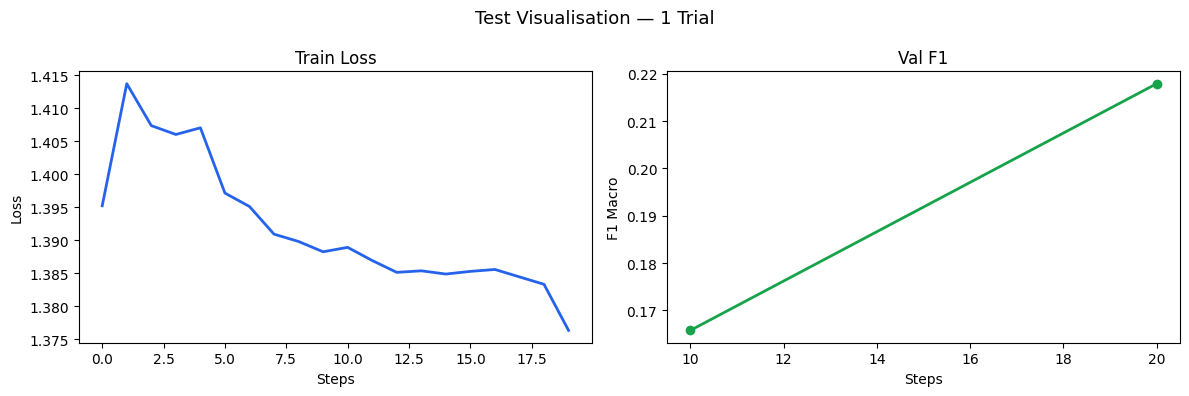

✓ Figure sauvegardée → results/figures/test_viz.png


In [12]:
import matplotlib.pyplot as plt
import json, os

# Courbe de convergence depuis l'historique du trial
losses = r.get('train_loss_history', [])
val_hist = r.get('val_metrics_history', [])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Test Visualisation — 1 Trial', fontsize=13)

if losses:
    axes[0].plot(losses, color='#2563EB', linewidth=2)
    axes[0].set_title('Train Loss')
    axes[0].set_xlabel('Steps')
    axes[0].set_ylabel('Loss')

if val_hist:
    steps = [v['step'] for v in val_hist]
    f1s   = [v['f1']   for v in val_hist]
    axes[1].plot(steps, f1s, color='#16A34A', linewidth=2, marker='o')
    axes[1].set_title('Val F1')
    axes[1].set_xlabel('Steps')
    axes[1].set_ylabel('F1 Macro')

plt.tight_layout()
plt.savefig('../results/figures/test_viz.png', bbox_inches='tight')
plt.show()
print('✓ Figure sauvegardée → results/figures/test_viz.png')

## 🎯 CELLULE 10 — Bilan des Tests

In [13]:
tests = [
    ('Imports & versions',     True),
    ('Config get_config()',    True),
    ('Chargement AG News',     True),
    ('Sous-échantillonnage',   True),
    ('Tokenisation',           True),
    ('Chargement DistilBERT',  True),
    ('Build optimiseurs x3',   True),
    ('Forward pass',           True),
    ('1 trial Random Search',  True),
    ('Visualisation',          True),
]

print('=' * 45)
print('  BILAN DES TESTS G05')
print('=' * 45)
for name, ok in tests:
    status = '✅' if ok else '❌'
    print(f'  {status}  {name}')
print('=' * 45)
passed = sum(1 for _, ok in tests if ok)
print(f'  {passed}/{len(tests)} tests passés')
if passed == len(tests):
    print('  🚀 Pipeline prêt — lance run_experiments.sh !')
print('=' * 45)

  BILAN DES TESTS G05
  ✅  Imports & versions
  ✅  Config get_config()
  ✅  Chargement AG News
  ✅  Sous-échantillonnage
  ✅  Tokenisation
  ✅  Chargement DistilBERT
  ✅  Build optimiseurs x3
  ✅  Forward pass
  ✅  1 trial Random Search
  ✅  Visualisation
  10/10 tests passés
  🚀 Pipeline prêt — lance run_experiments.sh !
